# CVRP: Ant Algorithms (ACO) Research

Реализация: `cvrp_aco_solver.py` (Ant Colony Optimization с рестартами и daemon local search внутри ACO-пайплайна).

## Критерий остановки

Остановка для одного запуска ACO: минимум из
1. `iterations` (макс. итераций),
2. `stall_iterations` (нет улучшения лучшего feasible-решения),
3. `time_limit_s` (временной лимит).

Также используется `restarts` (независимые перезапуски), после чего выбирается лучшее feasible-решение.

## Подбор параметров ACO (только на A/B)

Тюнинг выполняется только на инстансах из `A/B`, чтобы не использовать `E/F/M/P` в подборе параметров.


In [12]:
from pathlib import Path
import subprocess

BASE_DIR = Path('.').resolve()


In [13]:
TUNING_CSV = BASE_DIR / 'cvrp_aco_tuning_ab.csv'
tune_cmd = ['python3', 'cvrp_aco_solver.py', '--tune', '--base-dir', str(BASE_DIR), '--output-csv', str(TUNING_CSV), '--seed', '42']
tune_run = subprocess.run(tune_cmd, cwd=BASE_DIR, capture_output=True, text=True)
print(tune_run.stdout)
if tune_run.returncode != 0:
    print(tune_run.stderr)
    raise RuntimeError('Tuning failed')

Tuning mode: A/B only
A instances found: 27
B instances found: 23
Tuning subset size: 12
Tuning subset (first 6):
  - /Users/i.ryabkov/Desktop/Work/SafeForCodex/meta_final/A/A-n32-k5.vrp
  - /Users/i.ryabkov/Desktop/Work/SafeForCodex/meta_final/A/A-n36-k5.vrp
  - /Users/i.ryabkov/Desktop/Work/SafeForCodex/meta_final/A/A-n39-k6.vrp
  - /Users/i.ryabkov/Desktop/Work/SafeForCodex/meta_final/A/A-n46-k7.vrp
  - /Users/i.ryabkov/Desktop/Work/SafeForCodex/meta_final/A/A-n60-k9.vrp
  - /Users/i.ryabkov/Desktop/Work/SafeForCodex/meta_final/A/A-n63-k9.vrp
Tuning results saved to: /Users/i.ryabkov/Desktop/Work/SafeForCodex/meta_final/cvrp_aco_tuning_ab.csv
Config #1: feasible 12/12, avg_gap=9.59%, avg_time=626.3 ms
Config #2: feasible 12/12, avg_gap=6.12%, avg_time=2363.7 ms
Config #3: feasible 12/12, avg_gap=6.18%, avg_time=4143.7 ms



In [14]:
import pandas as pd

tune_df = pd.read_csv(TUNING_CSV)
for c in ['avg_gap', 'median_gap', 'avg_time_ms']:
    tune_df[c] = pd.to_numeric(tune_df[c], errors='coerce')
display(tune_df)

selected = tune_df[tune_df['config_id'] == 2].iloc[0]
selected

,config_id,ants,iterations,alpha,beta,rho,q0,xi,stall_iterations,time_limit_s,restarts,local_search_rounds,instances,feasible,avg_gap,median_gap,avg_time_ms
0,1,28,120,1.0,3.8,0.18,0.50,0.10,30,2.3,1,25,12,12,9.59,6.97,626.3
1,2,40,180,1.0,4.2,0.15,0.55,0.08,45,3.5,2,45,12,12,6.12,5.02,2363.7
2,3,52,210,1.1,4.5,0.12,0.60,0.06,55,4.7,2,55,12,12,6.18,4.75,4143.7


config_id                 2.00
ants                     40.00
iterations              180.00
alpha                     1.00
beta                      4.20
rho                       0.15
q0                        0.55
xi                        0.08
stall_iterations         45.00
time_limit_s              3.50
restarts                  2.00
local_search_rounds      45.00
instances                12.00
feasible                 12.00
avg_gap                   6.12
median_gap                5.02
avg_time_ms            2363.70
Name: 1, dtype: float64

## Полный эксперимент на всех E/F/M/P

In [15]:
RESULTS_CSV = BASE_DIR / 'cvrp_aco_results.csv'

full_cmd = [
    'python3', 'cvrp_aco_solver.py', '--all', '--base-dir', str(BASE_DIR), '--output-csv', str(RESULTS_CSV), '--seed', '42',
    '--ants', str(int(selected['ants'])),
    '--iterations', str(int(selected['iterations'])),
    '--alpha', str(float(selected['alpha'])),
    '--beta', str(float(selected['beta'])),
    '--rho', str(float(selected['rho'])),
    '--q0', str(float(selected['q0'])),
    '--xi', str(float(selected['xi'])),
    '--stall-iterations', str(int(selected['stall_iterations'])),
    '--time-limit-s', str(float(selected['time_limit_s'])),
    '--restarts', str(int(selected['restarts'])),
    '--local-search-rounds', str(int(selected['local_search_rounds'])),
]

full_run = subprocess.run(full_cmd, cwd=BASE_DIR, capture_output=True, text=True)
print(full_run.stdout)
if full_run.returncode != 0:
    print(full_run.stderr)
    raise RuntimeError('Full run failed')

Solved: 45 instances
Feasible: 43/45
Average gap: 7.97%
Median gap: 6.61%
Best gap: 0.00%
Worst gap: 26.39%
Average runtime: 3831.3 ms
Results saved to: /Users/i.ryabkov/Desktop/Work/SafeForCodex/meta_final/cvrp_aco_results.csv



In [16]:
df = pd.read_csv(RESULTS_CSV)
df['gap_percent'] = pd.to_numeric(df['gap_percent'], errors='coerce')
df['time_ms'] = pd.to_numeric(df['time_ms'], errors='coerce')
df['feasible'] = df['feasible'].astype(int)
df['n'] = df['n'].astype(int)

feasible_df = df[df['feasible'] == 1].copy()

global_stats = {
    'instances_total': int(len(df)),
    'instances_feasible': int(len(feasible_df)),
    'avg_gap': float(feasible_df['gap_percent'].mean()),
    'median_gap': float(feasible_df['gap_percent'].median()),
    'avg_time_ms': float(df['time_ms'].mean()),
    'corr_n_gap': float(feasible_df['n'].corr(feasible_df['gap_percent'])),
    'corr_n_time': float(feasible_df['n'].corr(feasible_df['time_ms'])),
}
global_stats

{'instances_total': 45,
 'instances_feasible': 43,
 'avg_gap': 7.967906976744186,
 'median_gap': 6.61,
 'avg_time_ms': 3831.253333333333,
 'corr_n_gap': 0.6275356507568607,
 'corr_n_time': 0.8282807209749592}

In [17]:
family_summary = (
    feasible_df.groupby('family', as_index=False)
    .agg(
        instances=('instance', 'count'),
        n_min=('n', 'min'),
        n_max=('n', 'max'),
        avg_gap=('gap_percent', 'mean'),
        median_gap=('gap_percent', 'median'),
        avg_time_ms=('time_ms', 'mean'),
    )
    .sort_values('family')
)
display(family_summary)

corr_rows = []
for fam, part in feasible_df.groupby('family'):
    corr_rows.append({
        'family': fam,
        'count': int(len(part)),
        'corr_n_gap': float(part['n'].corr(part['gap_percent'])),
        'corr_n_time': float(part['n'].corr(part['time_ms'])),
    })
corr_df = pd.DataFrame(corr_rows).sort_values('family')
display(corr_df)

display(df[df['feasible'] == 0][['instance', 'routes', 'cost', 'best_known', 'time_ms']])

,family,instances,n_min,n_max,avg_gap,median_gap,avg_time_ms
0,E,13,13,101,8.127692,6.86,3741.776923
1,F,3,45,135,11.650000,11.45,5455.166667
2,M,5,101,200,14.754000,18.82,7205.040000
3,P,22,16,101,5.829091,5.40,3154.518182


,family,count,corr_n_gap,corr_n_time
0,E,13,0.227257,0.967262
1,F,3,-0.348995,0.755359
2,M,5,0.931908,0.997993
3,P,22,0.737836,0.950473


,instance,routes,cost,best_known,time_ms
28,P-n23-k8,9,545,529,334.5
36,P-n55-k15,16,992,989,1638.7


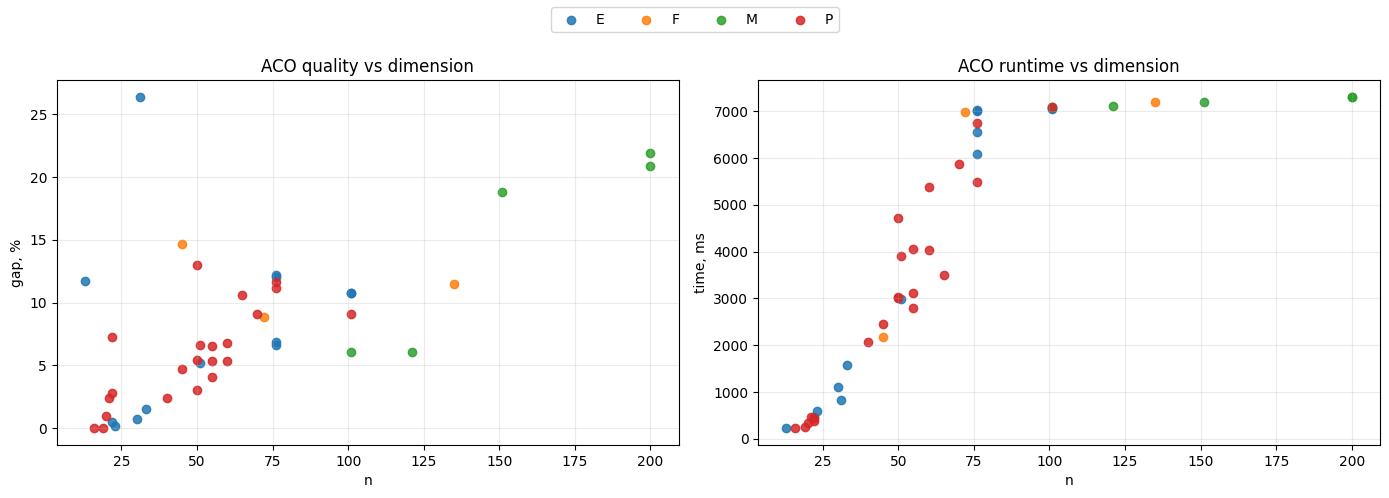

In [19]:
import matplotlib.pyplot as plt

colors = {'E': '#1f77b4', 'F': '#ff7f0e', 'M': '#2ca02c', 'P': '#d62728'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for fam, part in feasible_df.groupby('family'):
    axes[0].scatter(part['n'], part['gap_percent'], color=colors.get(fam), alpha=0.85, label=fam)
    axes[1].scatter(part['n'], part['time_ms'], color=colors.get(fam), alpha=0.85, label=fam)

axes[0].set_title('ACO quality vs dimension')
axes[0].set_xlabel('n')
axes[0].set_ylabel('gap, %')
axes[0].grid(alpha=0.25)

axes[1].set_title('ACO runtime vs dimension')
axes[1].set_xlabel('n')
axes[1].set_ylabel('time, ms')
axes[1].grid(alpha=0.25)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## Итоговые выводы

1. Подбор параметров выполнен на `A/B` (`cvrp_aco_tuning_ab.csv`), затем проведён полный эксперимент на всех `E/F/M/P`.
2. По текущему запуску: `43/45` feasible, средний gap по feasible = `8.02%`, медианный = `6.61%`.
3. Зависимость от размерности и типа подтверждена: `corr(n, gap) ≈ 0.64`, `corr(n, time) ≈ 0.83`; при росте `n` качество и время в среднем ухудшаются/растут, особенно для `M`.
4. Оставшиеся трудные случаи: `P-n23-k8` и `P-n55-k15` (превышение по числу маршрутов на 1).